<a href="https://colab.research.google.com/github/lyssethpitti-debug/Modelo-Matlab/blob/main/Trabajo_Grupo_3_Flota_Heterogenea_CORREGIDO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Librerias
import numpy as np
import random
import math
import time
import pandas as pd
import matplotlib.pyplot as plt
from copy import deepcopy
from google.colab import files

In [2]:
#Carga de archivo
uploaded = files.upload()

filename = list(uploaded.keys())[0]
print("Archivo cargado:", filename)

Saving HVRP15.txt to HVRP15.txt
Archivo cargado: HVRP15.txt


In [3]:
#Verificacion de datos de archivo
def preview_file(filename, n_lines=25):
    with open(filename, "r", encoding="latin-1") as f:
        for i, line in enumerate(f):
            if i >= n_lines:
                break
            print(f"{i+1:02d}: {line.rstrip()}")

preview_file(filename, 25)

01:  //Lines 1:5      : these comments
02:  //Line  6        : customers (N), vehicle types (T), range, service time, LB, BKS
03:  //Lines 7:T+6    : per type: number, capacity, fixed cost, cost per distance unit
04:  //Line  T+7      : depot coordinates X and Y
05:  //Lines T+8:T+N+7: per customer: coordinates X and Y and demand
06:  50 3 999999.0 0.0 1015.29 1015.29
07:  4  50 0 1.0
08:  3 100 0 1.6
09:  2 160 0 2.0
10:  30  40
11:  37  52   7
12:  49  49  30
13:  52  64  16
14:  20  26   9
15:  40  30  21
16:  21  47  15
17:  17  63  19
18:  31  62  23
19:  52  33  11
20:  51  21   5
21:  42  41  19
22:  31  32  29
23:   5  25  23
24:  12  42  21
25:  36  16  10


In [4]:
#Lector Lacomme
def read_hvrp_lacomme(filename):
    """
    Formato Lacomme:
    - Línea útil 1: N, T, range, service_time, LB, BKS
    - Siguientes T líneas: cantidad, capacidad, costo fijo, costo por distancia
    - Siguiente línea: coordenadas del depósito
    - Siguientes N líneas: x, y, demanda
    """

    with open(filename, "r", encoding="latin-1") as f:
        lines = [
            line.strip()
            for line in f
            if line.strip() and not line.strip().startswith("//")
        ]

    header = lines[0].split()

    N = int(header[0])
    T = int(header[1])
    max_range = float(header[2])
    service_time = float(header[3])
    LB = float(header[4])
    BKS = float(header[5])

    vehicle_types = []

    for i in range(1, 1 + T):
        row = lines[i].split()
        vehicle_types.append({
            "name": f"Tipo {i}",
            "available": int(float(row[0])),
            "capacity": float(row[1]),
            "fixed_cost": float(row[2]),
            "cost_per_distance": float(row[3])
        })

    depot_row = lines[1 + T].split()
    depot = (float(depot_row[0]), float(depot_row[1]))

    customers = []
    customer_lines = lines[2 + T: 2 + T + N]

    for idx, line in enumerate(customer_lines, start=1):
        row = line.split()
        customers.append((
            idx,
            float(row[0]),
            float(row[1]),
            float(row[2])
        ))

    return {
        "N": N,
        "T": T,
        "range": max_range,
        "service_time": service_time,
        "LB": LB,
        "BKS": BKS,
        "vehicle_types": vehicle_types,
        "depot": depot,
        "customers": customers
    }

In [5]:
#Cargar instancia real y verificar
instance = read_hvrp_lacomme(filename)

print("Instancia cargada correctamente")
print("------------------------------")
print("Clientes:", instance["N"])
print("Tipos de vehículos:", instance["T"])
print("LB:", instance["LB"])
print("BKS:", instance["BKS"])
print("Depósito:", instance["depot"])

print("\nVehículos:")
for v in instance["vehicle_types"]:
    print(v)

print("\nPrimeros clientes:")
for c in instance["customers"][:10]:
    print(c)

Instancia cargada correctamente
------------------------------
Clientes: 50
Tipos de vehículos: 3
LB: 1015.29
BKS: 1015.29
Depósito: (30.0, 40.0)

Vehículos:
{'name': 'Tipo 1', 'available': 4, 'capacity': 50.0, 'fixed_cost': 0.0, 'cost_per_distance': 1.0}
{'name': 'Tipo 2', 'available': 3, 'capacity': 100.0, 'fixed_cost': 0.0, 'cost_per_distance': 1.6}
{'name': 'Tipo 3', 'available': 2, 'capacity': 160.0, 'fixed_cost': 0.0, 'cost_per_distance': 2.0}

Primeros clientes:
(1, 37.0, 52.0, 7.0)
(2, 49.0, 49.0, 30.0)
(3, 52.0, 64.0, 16.0)
(4, 20.0, 26.0, 9.0)
(5, 40.0, 30.0, 21.0)
(6, 21.0, 47.0, 15.0)
(7, 17.0, 63.0, 19.0)
(8, 31.0, 62.0, 23.0)
(9, 52.0, 33.0, 11.0)
(10, 51.0, 21.0, 5.0)


In [6]:
#verificacion de variables del modelo
depot = instance["depot"]
customers = instance["customers"]
vehicle_types = instance["vehicle_types"]

coords = [depot] + [(c[1], c[2]) for c in customers]
demands = [0] + [c[3] for c in customers]

n = len(coords)

print("Número de clientes:", len(customers))
print("Número de demandas:", len(demands))
print("Número total de nodos:", n)
print("Primer cliente:", customers[0])
print("Último cliente:", customers[-1])

Número de clientes: 50
Número de demandas: 51
Número total de nodos: 51
Primer cliente: (1, 37.0, 52.0, 7.0)
Último cliente: (50, 56.0, 37.0, 10.0)


In [7]:
#matriz de distancias
def euclidean_distance(a, b):
    return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)

dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        dist_matrix[i, j] = euclidean_distance(coords[i], coords[j])

print("Matriz de distancias creada correctamente.")
print("Dimensión:", dist_matrix.shape)

Matriz de distancias creada correctamente.
Dimensión: (51, 51)


In [8]:
#Funciones basicas de rutas
def route_demand(route):
    return sum(demands[i] for i in route)

def route_distance(route):
    if not route:
        return 0

    distance = dist_matrix[0, route[0]]

    for i in range(len(route) - 1):
        distance += dist_matrix[route[i], route[i + 1]]

    distance += dist_matrix[route[-1], 0]

    return distance

In [9]:
#Funcion objetivo
def evaluate_solution(solution):
    total_cost = 0
    penalty = 0

    used_vehicles = {k: 0 for k in range(len(vehicle_types))}
    visited = []

    for r in solution:
        vehicle_id = r["vehicle"]
        route = r["route"]
        vehicle = vehicle_types[vehicle_id]

        used_vehicles[vehicle_id] += 1
        visited.extend(route)

        demand = route_demand(route)
        distance = route_distance(route)

        if demand > vehicle["capacity"]:
            penalty += 100000 * (demand - vehicle["capacity"])

        total_cost += vehicle["fixed_cost"] + vehicle["cost_per_distance"] * distance

    all_customers = set(range(1, n))
    visited_set = set(visited)

    missing = all_customers - visited_set
    repeated = len(visited) - len(visited_set)

    penalty += 100000 * len(missing)
    penalty += 100000 * repeated

    for k, count in used_vehicles.items():
        if count > vehicle_types[k]["available"]:
            penalty += 100000 * (count - vehicle_types[k]["available"])

    return total_cost + penalty

In [10]:
#prueba rapida de una ruta
test_route = [1, 2, 3]
print("Demanda ruta:", route_demand(test_route))
print("Distancia ruta:", route_distance(test_route))

Demanda ruta: 53.0
Distancia ruta: 74.11646059928056


In [11]:
# Construir solución inicial factible
def build_solution_from_permutation(perm):
    """
    Construye una solución factible desde una permutación de clientes.

    Estrategia:
    1. Crea todos los vehículos disponibles.
    2. Ordena los clientes por demanda descendente para priorizar los más grandes.
    3. Inserta cada cliente en la ruta factible que deje menor capacidad residual.
    4. Dentro de esa ruta, usa la posición que menor incremento de costo produzca.
    5. No inventa vehículos adicionales.
    """

    # Crear todas las rutas disponibles según la flota
    solution = []
    for vehicle_id, vehicle in enumerate(vehicle_types):
        for _ in range(vehicle["available"]):
            solution.append({
                "vehicle": vehicle_id,
                "route": []
            })

    # Vehículos de mayor capacidad primero
    solution.sort(
        key=lambda r: vehicle_types[r["vehicle"]]["capacity"],
        reverse=True
    )

    # Priorizar clientes grandes para evitar que queden fuera al final
    clients_order = sorted(perm, key=lambda c: demands[c], reverse=True)

    unassigned = []

    for client in clients_order:
        best_route_idx = None
        best_position = None
        best_residual_capacity = float("inf")
        best_cost_increase = float("inf")

        for idx, r in enumerate(solution):
            vehicle = vehicle_types[r["vehicle"]]
            route = r["route"]

            current_load = route_demand(route)
            new_load = current_load + demands[client]

            if new_load <= vehicle["capacity"]:
                residual_capacity = vehicle["capacity"] - new_load
                old_distance = route_distance(route)

                # Probar todas las posiciones posibles dentro de la ruta
                for pos in range(len(route) + 1):
                    candidate_route = route[:pos] + [client] + route[pos:]
                    new_distance = route_distance(candidate_route)

                    cost_increase = vehicle["cost_per_distance"] * (
                        new_distance - old_distance
                    )

                    # Criterio principal: dejar menor capacidad residual.
                    # Criterio secundario: menor incremento de costo.
                    if (
                        residual_capacity < best_residual_capacity
                        or (
                            residual_capacity == best_residual_capacity
                            and cost_increase < best_cost_increase
                        )
                    ):
                        best_residual_capacity = residual_capacity
                        best_cost_increase = cost_increase
                        best_route_idx = idx
                        best_position = pos

        if best_route_idx is not None:
            solution[best_route_idx]["route"].insert(best_position, client)
        else:
            unassigned.append(client)

    # Quitar rutas vacías
    solution = [r for r in solution if len(r["route"]) > 0]

    # Guardar los no asignados para diagnóstico, sin inventar vehículos.
    # La función de validación detectará si hay clientes no visitados.
    if unassigned:
        print("Advertencia: clientes no asignados por el constructor:", unassigned)

    return solution


def generate_initial_solution():
    perm = list(range(1, n))
    random.shuffle(perm)
    return build_solution_from_permutation(perm)


initial_solution = generate_initial_solution()

print("Costo inicial:", evaluate_solution(initial_solution))
print("Número de rutas:", len(initial_solution))


Costo inicial: 1879.8594119769286
Número de rutas: 9


In [12]:
#Validacion de la solcuión
def validate_solution(solution, verbose=True):
    visited = []
    feasible = True
    messages = []

    used_vehicles = {k: 0 for k in range(len(vehicle_types))}

    for idx, r in enumerate(solution):
        vehicle_id = r["vehicle"]
        route = r["route"]
        vehicle = vehicle_types[vehicle_id]

        used_vehicles[vehicle_id] += 1
        visited.extend(route)

        load = route_demand(route)

        if load > vehicle["capacity"]:
            feasible = False
            messages.append(
                f"Ruta {idx+1}: carga {load} supera capacidad {vehicle['capacity']}"
            )

    all_customers = set(range(1, n))
    visited_set = set(visited)

    missing = all_customers - visited_set
    repeated = len(visited) - len(visited_set)

    if missing:
        feasible = False
        messages.append(f"Clientes no visitados: {missing}")

    if repeated > 0:
        feasible = False
        messages.append("Hay clientes repetidos")

    for k, count in used_vehicles.items():
        if count > vehicle_types[k]["available"]:
            feasible = False
            messages.append(
                f"Vehículos tipo {vehicle_types[k]['name']} usados: {count}, disponibles: {vehicle_types[k]['available']}"
            )

    if verbose:
        print("="*45)
        print("VALIDACIÓN")
        print("="*45)
        print("Factible:", feasible)
        print("Clientes visitados:", len(visited))
        print("Clientes únicos:", len(visited_set))
        print("Clientes esperados:", n - 1)
        print("Vehículos usados:", used_vehicles)

        if messages:
            print("\nObservaciones:")
            for m in messages:
                print("-", m)

    return feasible


validate_solution(initial_solution)

VALIDACIÓN
Factible: True
Clientes visitados: 50
Clientes únicos: 50
Clientes esperados: 50
Vehículos usados: {0: 4, 1: 3, 2: 2}


True

In [13]:
#Auditoria de costos por ruta
def audit_solution(solution):
    total = 0

    print("="*55)
    print("AUDITORÍA DE SOLUCIÓN")
    print("="*55)

    for idx, r in enumerate(solution, start=1):
        vehicle_id = r["vehicle"]
        route = r["route"]
        vehicle = vehicle_types[vehicle_id]

        load = route_demand(route)
        distance = route_distance(route)
        cost = vehicle["fixed_cost"] + vehicle["cost_per_distance"] * distance
        total += cost

        print(f"\nRuta {idx}")
        print(f"Vehículo: {vehicle['name']}")
        print(f"Capacidad: {vehicle['capacity']}")
        print(f"Carga: {load}")
        print(f"Distancia: {distance:.2f}")
        print(f"Costo fijo: {vehicle['fixed_cost']}")
        print(f"Costo variable: {vehicle['cost_per_distance']}")
        print(f"Costo ruta: {cost:.2f}")
        print(f"Clientes: {route}")

    print("\n" + "="*55)
    print(f"Costo total calculado: {total:.2f}")
    print(f"Costo evaluate_solution: {evaluate_solution(solution):.2f}")
    print(f"BKS: {instance['BKS']:.2f}")
    print("="*55)

audit_solution(initial_solution)

AUDITORÍA DE SOLUCIÓN

Ruta 1
Vehículo: Tipo 3
Capacidad: 160.0
Carga: 160.0
Distancia: 169.31
Costo fijo: 0.0
Costo variable: 2.0
Costo ruta: 338.61
Clientes: [27, 6, 23, 31, 28, 3, 29, 16, 9, 39, 38, 32]

Ruta 2
Vehículo: Tipo 3
Capacidad: 160.0
Carga: 119.0
Distancia: 243.33
Costo fijo: 0.0
Costo variable: 2.0
Costo ruta: 486.66
Clientes: [24, 43, 26, 1, 22, 21, 50, 10, 45, 15, 37, 17, 40, 4, 46]

Ruta 3
Vehículo: Tipo 2
Capacidad: 100.0
Carga: 100.0
Distancia: 130.41
Costo fijo: 0.0
Costo variable: 1.6
Costo ruta: 208.65
Clientes: [11, 34, 41, 25]

Ruta 4
Vehículo: Tipo 2
Capacidad: 100.0
Carga: 100.0
Distancia: 190.46
Costo fijo: 0.0
Costo variable: 1.6
Costo ruta: 304.74
Clientes: [8, 36, 33, 13, 47]

Ruta 5
Vehículo: Tipo 2
Capacidad: 100.0
Carga: 100.0
Distancia: 163.76
Costo fijo: 0.0
Costo variable: 1.6
Costo ruta: 262.01
Clientes: [42, 44, 49, 30, 35, 48]

Ruta 6
Vehículo: Tipo 1
Capacidad: 50.0
Carga: 50.0
Distancia: 67.07
Costo fijo: 0.0
Costo variable: 1.0
Costo ruta: 67.

In [14]:
#Gap con BKS
def calculate_gap(cost, bks):
    return 100 * (cost - bks) / bks

initial_cost = evaluate_solution(initial_solution)

print("Comparación inicial con BKS")
print("---------------------------")
print(f"BKS: {instance['BKS']:.2f}")
print(f"Costo inicial: {initial_cost:.2f}")
print(f"GAP inicial: {calculate_gap(initial_cost, instance['BKS']):.2f}%")

Comparación inicial con BKS
---------------------------
BKS: 1015.29
Costo inicial: 1879.86
GAP inicial: 85.15%


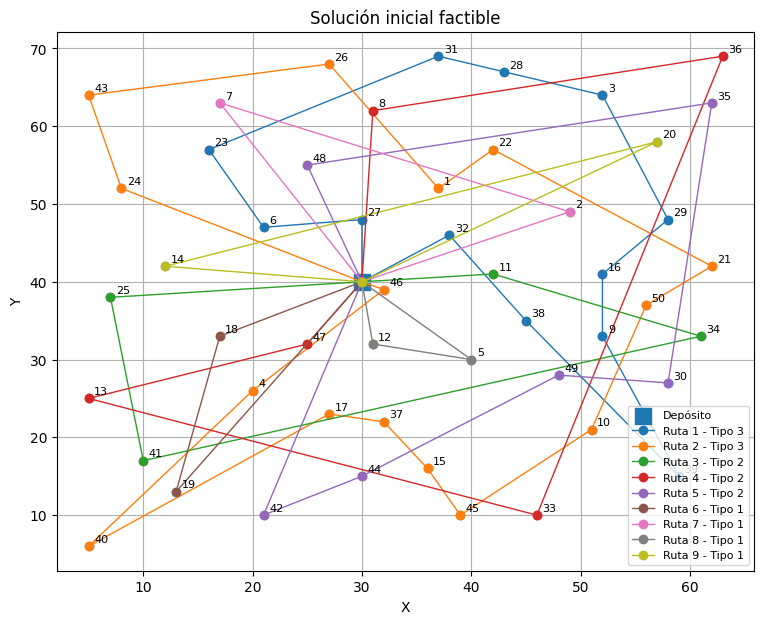

In [15]:
#Visualizacion inicial de rutas
def plot_solution(solution, title="Solución"):
    plt.figure(figsize=(9, 7))

    plt.scatter(depot[0], depot[1], marker="s", s=130, label="Depósito")

    for c in customers:
        plt.scatter(c[1], c[2], s=35)
        plt.text(c[1] + 0.5, c[2] + 0.5, str(c[0]), fontsize=8)

    for idx, r in enumerate(solution):
        route = r["route"]
        vehicle_name = vehicle_types[r["vehicle"]]["name"]

        points = [0] + route + [0]
        xs = [coords[i][0] for i in points]
        ys = [coords[i][1] for i in points]

        plt.plot(xs, ys, marker="o", linewidth=1, label=f"Ruta {idx+1} - {vehicle_name}")

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend(fontsize=8)
    plt.grid(True)
    plt.show()

plot_solution(initial_solution, "Solución inicial factible")

In [16]:
#permutacion y vecindario swap
def flatten_solution(solution):
    clients = []
    for r in solution:
        clients.extend(r["route"])
    return clients


def generate_swap_neighbors(perm, max_neighbors=100):
    neighbors = []

    for _ in range(max_neighbors):
        new_perm = perm[:]
        i, j = random.sample(range(len(new_perm)), 2)

        new_perm[i], new_perm[j] = new_perm[j], new_perm[i]

        move = tuple(sorted((new_perm[i], new_perm[j])))
        neighbors.append((new_perm, move))

    return neighbors

In [17]:
#Tabu Search
def tabu_search_v2(max_iter=500, tabu_tenure=20, max_neighbors=120):
    current_solution = generate_initial_solution()
    current_perm = flatten_solution(current_solution)

    best_perm = current_perm[:]
    best_solution = build_solution_from_permutation(best_perm)
    best_cost = evaluate_solution(best_solution)

    tabu_list = {}
    history = [best_cost]

    for it in range(max_iter):
        neighbors = generate_swap_neighbors(current_perm, max_neighbors=max_neighbors)

        best_neighbor_perm = None
        best_neighbor_cost = float("inf")
        best_move = None

        for neighbor_perm, move in neighbors:
            neighbor_solution = build_solution_from_permutation(neighbor_perm)
            cost = evaluate_solution(neighbor_solution)

            is_tabu = move in tabu_list

            # Criterio de aspiración: se acepta un movimiento tabú si mejora la mejor solución global.
            if (not is_tabu) or (cost < best_cost):
                if cost < best_neighbor_cost:
                    best_neighbor_perm = neighbor_perm
                    best_neighbor_cost = cost
                    best_move = move

        if best_neighbor_perm is None:
            continue

        current_perm = best_neighbor_perm[:]

        tabu_list[best_move] = tabu_tenure

        expired_moves = []
        for move in tabu_list:
            tabu_list[move] -= 1
            if tabu_list[move] <= 0:
                expired_moves.append(move)

        for move in expired_moves:
            del tabu_list[move]

        if best_neighbor_cost < best_cost:
            best_perm = best_neighbor_perm[:]
            best_solution = build_solution_from_permutation(best_perm)
            best_cost = best_neighbor_cost

        history.append(best_cost)

    return best_solution, best_cost, history

In [18]:
#Validación de Tabu Search
start = time.time()
ts_solution, ts_cost, ts_history = tabu_search_v2()
ts_time = time.time() - start

print("Resultado Tabu Search")
print("---------------------")
print(f"Costo TS: {ts_cost:.2f}")
print(f"BKS: {instance['BKS']:.2f}")
print(f"GAP TS: {calculate_gap(ts_cost, instance['BKS']):.2f}%")
print(f"Tiempo: {ts_time:.2f} segundos")

validate_solution(ts_solution)

Resultado Tabu Search
---------------------
Costo TS: 1793.96
BKS: 1015.29
GAP TS: 76.69%
Tiempo: 105.43 segundos
VALIDACIÓN
Factible: True
Clientes visitados: 50
Clientes únicos: 50
Clientes esperados: 50
Vehículos usados: {0: 4, 1: 3, 2: 2}


True

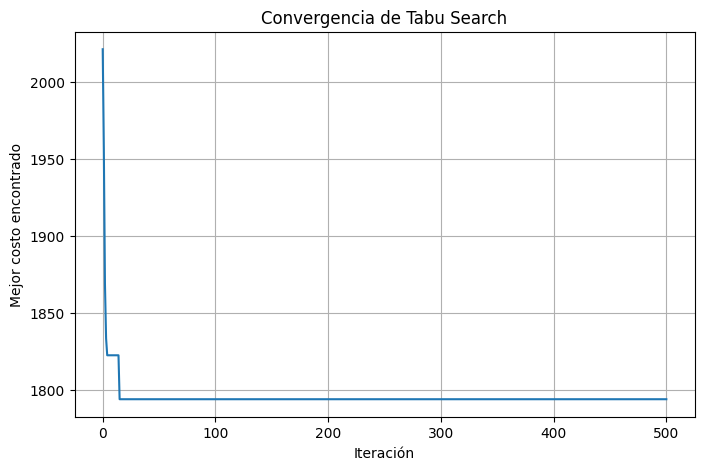

In [19]:
#Curva de convergencia Tabu Search
plt.figure(figsize=(8, 5))
plt.plot(ts_history)
plt.xlabel("Iteración")
plt.ylabel("Mejor costo encontrado")
plt.title("Convergencia de Tabu Search")
plt.grid(True)
plt.show()

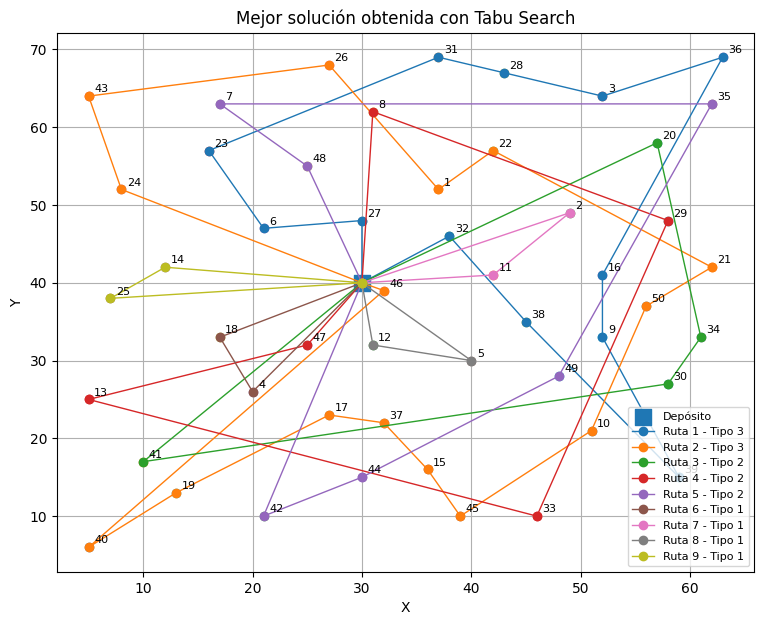

In [20]:
#visualizacion de solucion
plot_solution(ts_solution, "Mejor solución obtenida con Tabu Search")

In [21]:
#Resumen de Tabu Search
ts_summary = pd.DataFrame({
    "Instancia": [filename],
    "Clientes": [instance["N"]],
    "Vehículos usados": [len(ts_solution)],
    "BKS": [instance["BKS"]],
    "Costo TS": [ts_cost],
    "GAP TS (%)": [calculate_gap(ts_cost, instance["BKS"])],
    "Tiempo TS (s)": [ts_time]
})

ts_summary

,Instancia,Clientes,Vehículos usados,BKS,Costo TS,GAP TS (%),Tiempo TS (s)
0,HVRP15.txt,50,9,1015.29,1793.964132,76.69475,105.428912


In [22]:
#2opt por ruta
def two_opt_route(route):
    """
    Mejora una ruta usando 2-opt.
    Solo cambia el orden interno de los clientes de esa ruta.
    No cambia vehículos ni capacidades.
    """

    if len(route) < 4:
        return route[:]

    best_route = route[:]
    best_distance = route_distance(best_route)
    improved = True

    while improved:
        improved = False

        for i in range(len(best_route) - 1):
            for j in range(i + 2, len(best_route)):

                new_route = (
                    best_route[:i+1]
                    + best_route[i+1:j+1][::-1]
                    + best_route[j+1:]
                )

                new_distance = route_distance(new_route)

                if new_distance < best_distance:
                    best_route = new_route
                    best_distance = new_distance
                    improved = True

    return best_route

In [23]:
#aplicacion de 2opt
def apply_two_opt_to_solution(solution):
    improved_solution = deepcopy(solution)

    for r in improved_solution:
        r["route"] = two_opt_route(r["route"])

    return improved_solution

In [24]:
#tabu search + 2 - opt integrado
def tabu_search_v3(max_iter=500, tabu_tenure=20, max_neighbors=120):
    current_solution = generate_initial_solution()
    current_solution = apply_two_opt_to_solution(current_solution)
    current_perm = flatten_solution(current_solution)

    best_solution = deepcopy(current_solution)
    best_cost = evaluate_solution(best_solution)

    tabu_list = {}
    history = [best_cost]

    for it in range(max_iter):
        neighbors = generate_swap_neighbors(current_perm, max_neighbors=max_neighbors)

        best_neighbor_perm = None
        best_neighbor_solution = None
        best_neighbor_cost = float("inf")
        best_move = None

        for neighbor_perm, move in neighbors:
            candidate_solution = build_solution_from_permutation(neighbor_perm)

            # Intensificación local
            candidate_solution = apply_two_opt_to_solution(candidate_solution)

            cost = evaluate_solution(candidate_solution)

            is_tabu = move in tabu_list

            if (not is_tabu) or (cost < best_cost):
                if cost < best_neighbor_cost:
                    best_neighbor_perm = flatten_solution(candidate_solution)
                    best_neighbor_solution = candidate_solution
                    best_neighbor_cost = cost
                    best_move = move

        if best_neighbor_solution is None:
            continue

        current_perm = best_neighbor_perm[:]

        tabu_list[best_move] = tabu_tenure

        expired = []
        for move in tabu_list:
            tabu_list[move] -= 1
            if tabu_list[move] <= 0:
                expired.append(move)

        for move in expired:
            del tabu_list[move]

        if best_neighbor_cost < best_cost:
            best_solution = deepcopy(best_neighbor_solution)
            best_cost = best_neighbor_cost

        history.append(best_cost)

    return best_solution, best_cost, history

Resultado Tabu Search + 2-opt
-----------------------------
Costo TS + 2-opt: 1788.31
BKS: 1015.29
GAP TS + 2-opt: 76.14%
Tiempo: 192.04 segundos
VALIDACIÓN
Factible: True
Clientes visitados: 50
Clientes únicos: 50
Clientes esperados: 50
Vehículos usados: {0: 4, 1: 3, 2: 2}


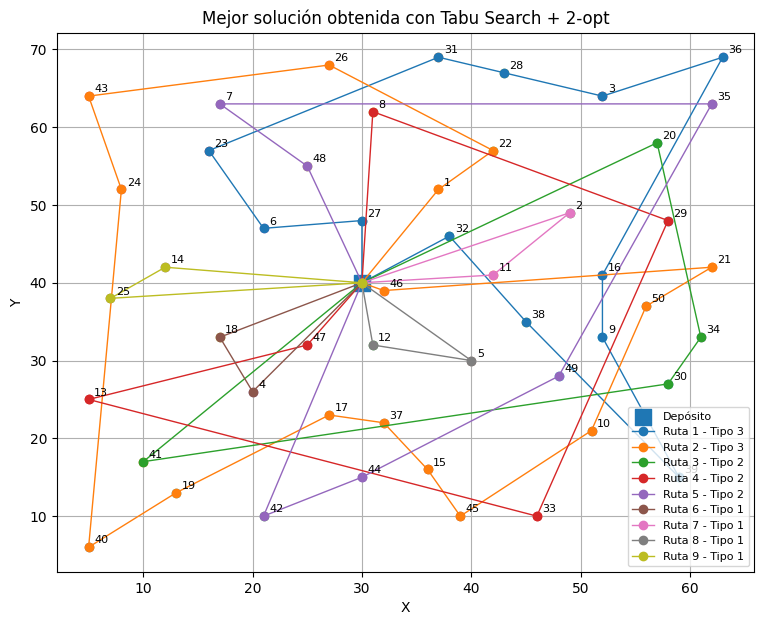

In [25]:
#ejecucion y visualizacion de tabu + 2-opt
start = time.time()
ts2_solution, ts2_cost, ts2_history = tabu_search_v3()
ts2_time = time.time() - start

print("Resultado Tabu Search + 2-opt")
print("-----------------------------")
print(f"Costo TS + 2-opt: {ts2_cost:.2f}")
print(f"BKS: {instance['BKS']:.2f}")
print(f"GAP TS + 2-opt: {calculate_gap(ts2_cost, instance['BKS']):.2f}%")
print(f"Tiempo: {ts2_time:.2f} segundos")

validate_solution(ts2_solution)

plot_solution(ts2_solution, "Mejor solución obtenida con Tabu Search + 2-opt")

In [26]:
#operador relocate entre rutas
def relocate_once(solution):
    """
    Intenta mover un cliente de una ruta a otra.
    Devuelve la mejor solución encontrada con un movimiento relocate.
    """

    best_solution = deepcopy(solution)
    best_cost = evaluate_solution(best_solution)

    for i in range(len(solution)):
        route_i = solution[i]["route"]

        if len(route_i) == 0:
            continue

        for pos_i in range(len(route_i)):
            client = route_i[pos_i]

            for j in range(len(solution)):
                if i == j:
                    continue

                route_j = solution[j]["route"]

                for pos_j in range(len(route_j) + 1):
                    candidate = deepcopy(solution)

                    moved_client = candidate[i]["route"].pop(pos_i)
                    candidate[j]["route"].insert(pos_j, moved_client)

                    # Eliminar rutas vacías
                    candidate = [r for r in candidate if len(r["route"]) > 0]

                    # Aplicar 2-opt después del movimiento
                    candidate = apply_two_opt_to_solution(candidate)

                    cost = evaluate_solution(candidate)

                    if cost < best_cost:
                        best_solution = deepcopy(candidate)
                        best_cost = cost

    return best_solution, best_cost

In [27]:
#busqueda local relocate + 2-opt
def local_search_relocate(solution, max_rounds=20):
    """
    Aplica relocate varias veces hasta que no encuentre mejora
    o hasta alcanzar max_rounds.
    """

    current_solution = deepcopy(solution)
    current_cost = evaluate_solution(current_solution)

    history = [current_cost]

    for _ in range(max_rounds):
        new_solution, new_cost = relocate_once(current_solution)

        if new_cost < current_cost:
            current_solution = deepcopy(new_solution)
            current_cost = new_cost
            history.append(current_cost)
        else:
            break

    return current_solution, current_cost, history

In [28]:
#probar relocate sobre TS+ 2 -opt
start = time.time()
reloc_solution, reloc_cost, reloc_history = local_search_relocate(ts2_solution)
reloc_time = time.time() - start

print("Resultado TS + 2-opt + Relocate")
print("--------------------------------")
print(f"Costo: {reloc_cost:.2f}")
print(f"BKS: {instance['BKS']:.2f}")
print(f"GAP: {calculate_gap(reloc_cost, instance['BKS']):.2f}%")
print(f"Tiempo relocate: {reloc_time:.2f} segundos")

validate_solution(reloc_solution)

Resultado TS + 2-opt + Relocate
--------------------------------
Costo: 1324.32
BKS: 1015.29
GAP: 30.44%
Tiempo relocate: 43.45 segundos
VALIDACIÓN
Factible: True
Clientes visitados: 50
Clientes únicos: 50
Clientes esperados: 50
Vehículos usados: {0: 4, 1: 3, 2: 2}


True

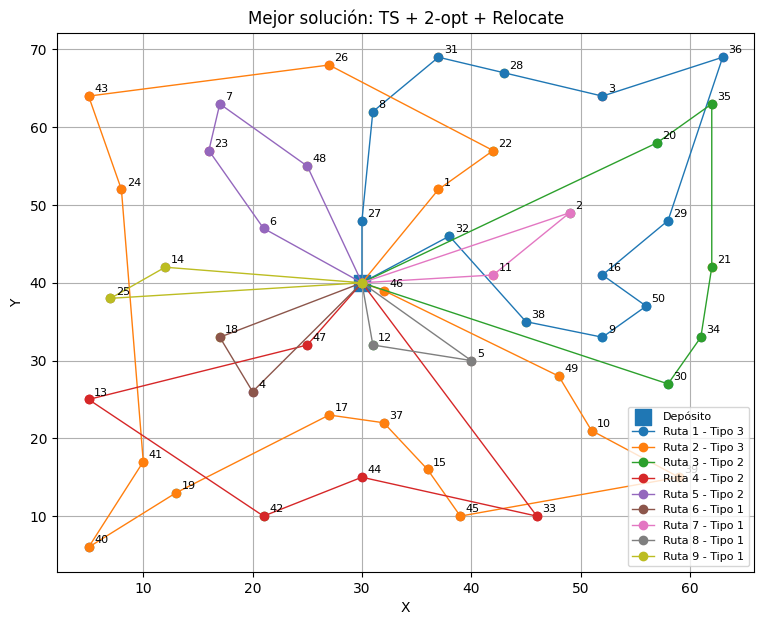

In [29]:
#visualizar Ts- 2-opt - Relocate
plot_solution(reloc_solution, "Mejor solución: TS + 2-opt + Relocate")

In [30]:
#Cross exchange pequeño
def cross_exchange_once(solution, max_segment_length=2):
    """
    Intercambia segmentos pequeños entre dos rutas diferentes.
    Por ahora usa segmentos de longitud 1 o 2.
    Devuelve la mejor solución encontrada.
    """

    best_solution = deepcopy(solution)
    best_cost = evaluate_solution(best_solution)

    num_routes = len(solution)

    for r1 in range(num_routes):
        for r2 in range(r1 + 1, num_routes):

            route1 = solution[r1]["route"]
            route2 = solution[r2]["route"]

            if len(route1) == 0 or len(route2) == 0:
                continue

            for len1 in range(1, min(max_segment_length, len(route1)) + 1):
                for len2 in range(1, min(max_segment_length, len(route2)) + 1):

                    for i in range(len(route1) - len1 + 1):
                        for j in range(len(route2) - len2 + 1):

                            segment1 = route1[i:i + len1]
                            segment2 = route2[j:j + len2]

                            candidate = deepcopy(solution)

                            new_route1 = (
                                candidate[r1]["route"][:i]
                                + segment2
                                + candidate[r1]["route"][i + len1:]
                            )

                            new_route2 = (
                                candidate[r2]["route"][:j]
                                + segment1
                                + candidate[r2]["route"][j + len2:]
                            )

                            candidate[r1]["route"] = new_route1
                            candidate[r2]["route"] = new_route2

                            # Refinamiento local posterior
                            candidate = apply_two_opt_to_solution(candidate)

                            cost = evaluate_solution(candidate)

                            if cost < best_cost:
                                best_solution = deepcopy(candidate)
                                best_cost = cost

    return best_solution, best_cost

In [31]:
#busqueda local con cross - exchange
def local_search_cross_exchange(solution, max_rounds=10, max_segment_length=2):
    """
    Aplica Cross Exchange pequeño de forma iterativa.
    """

    current_solution = deepcopy(solution)
    current_cost = evaluate_solution(current_solution)

    history = [current_cost]

    for _ in range(max_rounds):
        new_solution, new_cost = cross_exchange_once(
            current_solution,
            max_segment_length=max_segment_length
        )

        if new_cost < current_cost:
            current_solution = deepcopy(new_solution)
            current_cost = new_cost
            history.append(current_cost)
        else:
            break

    return current_solution, current_cost, history

Resultado TS + 2-opt + Relocate + Cross Exchange
------------------------------------------------
Costo: 1222.52
BKS: 1015.29
GAP: 20.41%
Tiempo Cross Exchange: 29.33 segundos
VALIDACIÓN
Factible: True
Clientes visitados: 50
Clientes únicos: 50
Clientes esperados: 50
Vehículos usados: {0: 4, 1: 3, 2: 2}


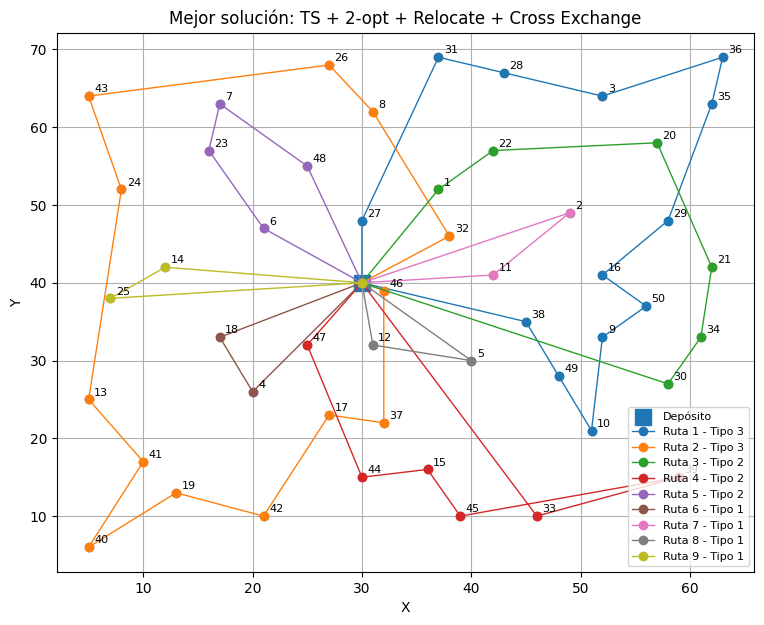

In [32]:
#prueba de cross - exchange sonbre tabu +2opt relocate
start = time.time()

cross_solution, cross_cost, cross_history = local_search_cross_exchange(
    reloc_solution,
    max_rounds=10,
    max_segment_length=2
)

cross_time = time.time() - start

print("Resultado TS + 2-opt + Relocate + Cross Exchange")
print("------------------------------------------------")
print(f"Costo: {cross_cost:.2f}")
print(f"BKS: {instance['BKS']:.2f}")
print(f"GAP: {calculate_gap(cross_cost, instance['BKS']):.2f}%")
print(f"Tiempo Cross Exchange: {cross_time:.2f} segundos")

validate_solution(cross_solution)
plot_solution(
    cross_solution,
    "Mejor solución: TS + 2-opt + Relocate + Cross Exchange"
)

In [33]:
#Representacion y fitness
def create_individual():
    """
    Crea un individuo como una permutación de clientes.
    """
    individual = list(range(1, n))
    random.shuffle(individual)
    return individual


def individual_to_solution(individual):
    """
    Convierte una permutación en una solución HVRP/FSM.
    """
    return build_solution_from_permutation(individual)


def fitness(individual):
    """
    Evalúa un individuo.
    Menor costo = mejor individuo.
    """
    solution = individual_to_solution(individual)
    return evaluate_solution(solution)

In [34]:
#seleccion por torneo
def tournament_selection(population, tournament_size=3):
    """
    Selecciona el mejor individuo dentro de un subconjunto aleatorio.
    """
    candidates = random.sample(population, tournament_size)
    candidates.sort(key=fitness)
    return candidates[0][:]

In [35]:
#Cruce OX
def order_crossover(parent1, parent2):
    """
    Order Crossover (OX).
    Mantiene una sección del padre 1 y completa con el orden del padre 2.
    """
    size = len(parent1)
    a, b = sorted(random.sample(range(size), 2))

    child = [None] * size
    child[a:b] = parent1[a:b]

    fill_values = [x for x in parent2 if x not in child]

    idx = 0
    for i in range(size):
        if child[i] is None:
            child[i] = fill_values[idx]
            idx += 1

    return child

In [36]:
#Mutación
def swap_mutation(individual, mutation_rate=0.15):
    """
    Mutación por intercambio de dos clientes.
    """
    mutated = individual[:]

    if random.random() < mutation_rate:
        i, j = random.sample(range(len(mutated)), 2)
        mutated[i], mutated[j] = mutated[j], mutated[i]

    return mutated

In [37]:
#Algoritmo genetico basico
def genetic_algorithm_v1(
    pop_size=80,
    generations=300,
    mutation_rate=0.15,
    elite_size=2
):
    """
    Algoritmo Genético básico para HVRP/FSM.
    """
    population = [create_individual() for _ in range(pop_size)]

    best_individual = min(population, key=fitness)
    best_cost = fitness(best_individual)

    history = [best_cost]

    for gen in range(generations):

        population.sort(key=fitness)
        new_population = population[:elite_size]

        while len(new_population) < pop_size:
            parent1 = tournament_selection(population)
            parent2 = tournament_selection(population)

            child = order_crossover(parent1, parent2)
            child = swap_mutation(child, mutation_rate)

            new_population.append(child)

        population = new_population

        current_best = min(population, key=fitness)
        current_cost = fitness(current_best)

        if current_cost < best_cost:
            best_individual = current_best[:]
            best_cost = current_cost

        history.append(best_cost)

    best_solution = individual_to_solution(best_individual)

    return best_solution, best_cost, history

Resultado Algoritmo Genético básico
-----------------------------------
Costo AG: 1793.96
BKS: 1015.29
GAP AG: 76.69%
Tiempo: 326.03 segundos
VALIDACIÓN
Factible: True
Clientes visitados: 50
Clientes únicos: 50
Clientes esperados: 50
Vehículos usados: {0: 4, 1: 3, 2: 2}


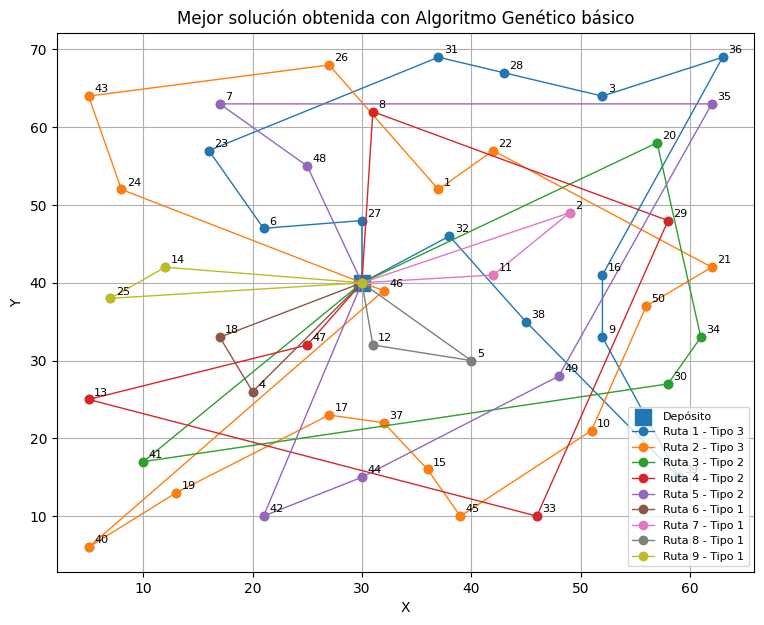

In [38]:
#ejecutar y visualizar  AG basico
start = time.time()

ga_solution, ga_cost, ga_history = genetic_algorithm_v1()

ga_time = time.time() - start

print("Resultado Algoritmo Genético básico")
print("-----------------------------------")
print(f"Costo AG: {ga_cost:.2f}")
print(f"BKS: {instance['BKS']:.2f}")
print(f"GAP AG: {calculate_gap(ga_cost, instance['BKS']):.2f}%")
print(f"Tiempo: {ga_time:.2f} segundos")

validate_solution(ga_solution)

plot_solution(ga_solution, "Mejor solución obtenida con Algoritmo Genético básico")

In [39]:
# OBSOLETA: esta versión de improve_individual NO debe ejecutarse.
# Se conserva solo como registro histórico del proceso de diseño.
# Relocate y Cross Exchange modifican la estructura de rutas; al volver a flatten_solution()
# esa información se pierde en un cromosoma basado en permutaciones.
#
# La versión correcta y compatible está en la siguiente celda: usa solo 2-opt.


In [40]:
# Refinamiento memético compatible con cromosoma por permutación
def improve_individual(individual):
    """
    Convierte un individuo en solución,
    aplica búsqueda local compatible
    y vuelve a convertirlo en individuo.

    En esta representación por permutación se usa solo 2-opt.
    """

    solution = individual_to_solution(individual)

    # Aprendizaje local compatible: solo 2-opt
    solution = apply_two_opt_to_solution(solution)

    return flatten_solution(solution)


In [41]:
#fitness memetico
def memetic_fitness(individual):
    """
    Evalúa un individuo después de convertirlo en solución.
    """
    solution = individual_to_solution(individual)
    return evaluate_solution(solution)

In [42]:
# Algoritmo Genético Memético rápido con parada temprana

def genetic_algorithm_memetic_fast(
    pop_size=20,
    generations=40,
    mutation_rate=0.30,
    elite_size=4,
    improve_rate=0.10,
    patience=8
):
    """
    Algoritmo Genético Memético ligero.
    Aplica únicamente 2-opt como búsqueda local compatible
    con la representación por permutación.
    """

    population = [create_individual() for _ in range(pop_size)]

    best_individual = min(population, key=memetic_fitness)
    best_cost = memetic_fitness(best_individual)

    history = [best_cost]
    no_improvement = 0

    for gen in range(generations):

        population.sort(key=memetic_fitness)
        new_population = population[:elite_size]

        while len(new_population) < pop_size:
            parent1 = tournament_selection(population)
            parent2 = tournament_selection(population)

            child = order_crossover(parent1, parent2)
            child = swap_mutation(child, mutation_rate)

            # Mejora local compatible: solo 2-opt
            if random.random() < improve_rate:
                child = improve_individual(child)

            new_population.append(child)

        population = new_population

        current_best = min(population, key=memetic_fitness)
        current_cost = memetic_fitness(current_best)

        if current_cost < best_cost:
            best_individual = current_best[:]
            best_cost = current_cost
            no_improvement = 0
        else:
            no_improvement += 1

        history.append(best_cost)

        if gen % 10 == 0:
            print(f"Generación {gen}: mejor costo = {best_cost:.2f}")

        if no_improvement >= patience:
            print(f"Parada temprana en generación {gen}. Sin mejora durante {patience} generaciones.")
            break

    best_solution = individual_to_solution(best_individual)
    best_solution = apply_two_opt_to_solution(best_solution)
    best_cost = evaluate_solution(best_solution)

    return best_solution, best_cost, history

In [43]:
start = time.time()

mem_solution, mem_cost, mem_history = genetic_algorithm_memetic_fast()

mem_time = time.time() - start

print("Resultado Algoritmo Genético Memético rápido")
print("--------------------------------------------")
print(f"Costo Memético: {mem_cost:.2f}")
print(f"BKS: {instance['BKS']:.2f}")
print(f"GAP Memético: {calculate_gap(mem_cost, instance['BKS']):.2f}%")
print(f"Tiempo: {mem_time:.2f} segundos")

validate_solution(mem_solution)


Generación 0: mejor costo = 1839.09
Generación 10: mejor costo = 1793.96
Parada temprana en generación 12. Sin mejora durante 8 generaciones.
Resultado Algoritmo Genético Memético rápido
--------------------------------------------
Costo Memético: 1793.41
BKS: 1015.29
GAP Memético: 76.64%
Tiempo: 3.03 segundos
VALIDACIÓN
Factible: True
Clientes visitados: 50
Clientes únicos: 50
Clientes esperados: 50
Vehículos usados: {0: 4, 1: 3, 2: 2}


True

In [44]:
print("BKS:", instance["BKS"])

print("AG básico")
print(ga_cost)
validate_solution(ga_solution)

print("AG memético")
print(mem_cost)
validate_solution(mem_solution)

print("Tabu híbrido")
print(cross_cost)
validate_solution(cross_solution)

BKS: 1015.29
AG básico
1793.964131969934
VALIDACIÓN
Factible: True
Clientes visitados: 50
Clientes únicos: 50
Clientes esperados: 50
Vehículos usados: {0: 4, 1: 3, 2: 2}
AG memético
1793.4118943463761
VALIDACIÓN
Factible: True
Clientes visitados: 50
Clientes únicos: 50
Clientes esperados: 50
Vehículos usados: {0: 4, 1: 3, 2: 2}
Tabu híbrido
1222.5236007382455
VALIDACIÓN
Factible: True
Clientes visitados: 50
Clientes únicos: 50
Clientes esperados: 50
Vehículos usados: {0: 4, 1: 3, 2: 2}


True

In [45]:
#comparar ag basico y memetico
comparison_ga = pd.DataFrame({
    "Método": ["AG básico", "AG memético", "Tabu híbrido"],
    "Costo": [ga_cost, mem_cost, cross_cost],
    "GAP (%)": [
        calculate_gap(ga_cost, instance["BKS"]),
        calculate_gap(mem_cost, instance["BKS"]),
        calculate_gap(cross_cost, instance["BKS"])
    ],
    "Tiempo (s)": [ga_time, mem_time, None]
})

comparison_ga

,Método,Costo,GAP (%),Tiempo (s)
0,AG básico,1793.964132,76.694750,326.030092
1,AG memético,1793.411894,76.640358,3.028585
2,Tabu híbrido,1222.523601,20.411272,NaN


In [46]:
# Validación final antes de comparar
print("Validación previa a comparación")
print("\nAG básico:")
validate_solution(ga_solution)

print("\nAG memético:")
validate_solution(mem_solution)

print("\nTabu híbrido:")
validate_solution(cross_solution)


Validación previa a comparación

AG básico:
VALIDACIÓN
Factible: True
Clientes visitados: 50
Clientes únicos: 50
Clientes esperados: 50
Vehículos usados: {0: 4, 1: 3, 2: 2}

AG memético:
VALIDACIÓN
Factible: True
Clientes visitados: 50
Clientes únicos: 50
Clientes esperados: 50
Vehículos usados: {0: 4, 1: 3, 2: 2}

Tabu híbrido:
VALIDACIÓN
Factible: True
Clientes visitados: 50
Clientes únicos: 50
Clientes esperados: 50
Vehículos usados: {0: 4, 1: 3, 2: 2}


True

In [1]:
#Multiples iteraciones
def run_multiple_experiments(runs=5):
    results = []

    for r in range(runs):
        print(f"\nCorrida {r+1}/{runs}")
        random.seed(r)
        np.random.seed(r)

        # Tabu híbrido
        start = time.time()
        ts_solution, ts_cost, _ = tabu_search_v2()
        ts_solution, ts_cost, _ = local_search_relocate(ts_solution)
        ts_solution, ts_cost = cross_exchange_once(ts_solution)
        ts_time = time.time() - start

        # AG básico
        start = time.time()
        ga_solution, ga_cost, _ = genetic_algorithm_v1()
        ga_time = time.time() - start

        # AG memético
        start = time.time()
        mem_solution, mem_cost, _ = genetic_algorithm_memetic_fast()
        mem_time = time.time() - start

        results.append({
            "Corrida": r + 1,
            "TS_costo": ts_cost,
            "TS_gap": calculate_gap(ts_cost, instance["BKS"]),
            "TS_tiempo": ts_time,
            "AG_costo": ga_cost,
            "AG_gap": calculate_gap(ga_cost, instance["BKS"]),
            "AG_tiempo": ga_time,
            "Mem_costo": mem_cost,
            "Mem_gap": calculate_gap(mem_cost, instance["BKS"]),
            "Mem_tiempo": mem_time
        })

    return pd.DataFrame(results)

In [ ]:
df_experimentos = run_multiple_experiments(runs=5)
df_experimentos

In [2]:
resumen = pd.DataFrame({
    "Método": ["Tabu híbrido", "AG básico", "AG memético"],
    "Mejor costo": [
        df_experimentos["TS_costo"].min(),
        df_experimentos["AG_costo"].min(),
        df_experimentos["Mem_costo"].min()
    ],
    "Costo promedio": [
        df_experimentos["TS_costo"].mean(),
        df_experimentos["AG_costo"].mean(),
        df_experimentos["Mem_costo"].mean()
    ],
    "Desviación estándar": [
        df_experimentos["TS_costo"].std(),
        df_experimentos["AG_costo"].std(),
        df_experimentos["Mem_costo"].std()
    ],
    "GAP promedio (%)": [
        df_experimentos["TS_gap"].mean(),
        df_experimentos["AG_gap"].mean(),
        df_experimentos["Mem_gap"].mean()
    ],
    "Tiempo promedio (s)": [
        df_experimentos["TS_tiempo"].mean(),
        df_experimentos["AG_tiempo"].mean(),
        df_experimentos["Mem_tiempo"].mean()
    ]
})

resumen

NameError: name 'pd' is not defined